In [11]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.optim import Adam
import torchaudio
import torch.nn.functional as F
import os
from torch.utils.data import DataLoader,Dataset
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import os
import time
from skimage.transform import resize

device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)


cuda


In [2]:
df=pd.read_csv(r'C:\Coding\ML_DL\Datasets\Dataset\Dataset\files_paths.csv')
df.head()




,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan


In [3]:
df['FilePath']=r'C:\Coding\ML_DL\Datasets\Dataset'+df['FilePath'].str[1:]
df.head()

,FilePath,Class
0,C:\Coding\ML_DL\Datasets\Dataset/Dataset/Moham...,Mohammed_Aluhaidan
1,C:\Coding\ML_DL\Datasets\Dataset/Dataset/Moham...,Mohammed_Aluhaidan
2,C:\Coding\ML_DL\Datasets\Dataset/Dataset/Moham...,Mohammed_Aluhaidan
3,C:\Coding\ML_DL\Datasets\Dataset/Dataset/Moham...,Mohammed_Aluhaidan
4,C:\Coding\ML_DL\Datasets\Dataset/Dataset/Moham...,Mohammed_Aluhaidan


data shape (6687, 2)
data dsit Class
Saud_Alshuraim          696
Saad_Alghamdi           688
AbdulRahman_Alsudais    648
Yasser_Aldossary        576
Ali_Alhothaify          576
Bander_Balilah          576
Maher_Almuaiqly         576
Abdullah_Albuaijan      504
Mohammed_Ayoub          480
Nasser_Alqutami         456
AbdulBari_Althubaity    456
Mohammed_Aluhaidan      455
Name: count, dtype: int64


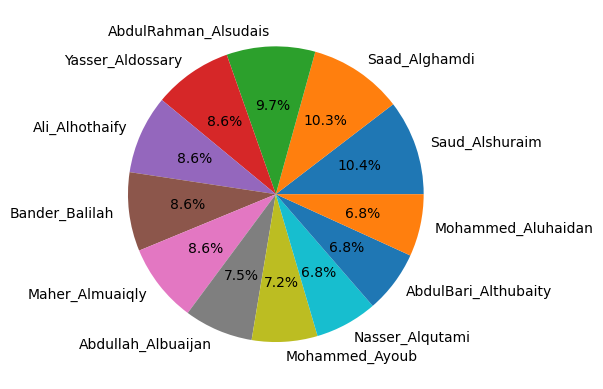

In [4]:
print("data shape",df.shape)
print("data dsit",df['Class'].value_counts())

plt.pie(df['Class'].value_counts(),labels=df['Class'].value_counts().index,autopct='%1.1f%%')
plt.show()

In [5]:
le=LabelEncoder()
df['Class']=le.fit_transform(df['Class'])

In [6]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

val,test_df=train_test_split(
    test,
    test_size=0.5,
    random_state=42,
    shuffle=True
)
print(f"Train shape:{train.shape}")
print(f"Test shape:{test_df.shape}")
print(f"Validation shape:{val.shape}")

Train shape:(4680, 2)
Test shape:(1004, 2)
Validation shape:(1003, 2)


In [7]:
SAMPLE_RATE = 22050
DURATION = 5  # seconds
NUM_SAMPLES = SAMPLE_RATE * DURATION

N_MELS = 128
IMG_W = 256
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=2048,
    hop_length=512,
    n_mels=N_MELS
).to(device)

db_transform = torchaudio.transforms.AmplitudeToDB().to(device)


def load_audio(file_path):
    waveform, sr = torchaudio.load(file_path)

    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(
            waveform, sr, SAMPLE_RATE
        )

    waveform = waveform.mean(dim=0, keepdim=True)  # mono

    # pad / trim
    if waveform.shape[1] < NUM_SAMPLES:
        pad = NUM_SAMPLES - waveform.shape[1]
        waveform = F.pad(waveform, (0, pad))
    else:
        waveform = waveform[:, :NUM_SAMPLES]

    return waveform.to(device)


def compute_mel_spec(file_path):
    waveform = load_audio(file_path)

    mel = mel_transform(waveform)
    mel_db = db_transform(mel)

    # Resize time axis → IMG_W
    mel_db = F.interpolate(
        mel_db.unsqueeze(0),
        size=(N_MELS, IMG_W),
        mode="bilinear",
        align_corners=False
    ).squeeze(0)

    return mel_db.cpu()  # (1, 128, 256)


def preprocess_and_save(df, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    for idx, row in df.iterrows():
        spec = compute_mel_spec(row["FilePath"])
        save_path = os.path.join(save_dir, f"{idx}.pt")
        torch.save(spec, save_path)


In [8]:
class CustomAudioDataset(Dataset):
    def __init__(self, df, spec_dir):
        self.df = df.reset_index(drop=True)
        self.labels = torch.LongTensor(df["Class"].values)
        self.spec_dir = spec_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        spec_path = f"{self.spec_dir}/{idx}.pt"
        spec = torch.load(spec_path)  # (1, 128, 256)
        label = self.labels[idx]

        return spec, label


In [9]:
train = train.reset_index(drop=True)
val   = val.reset_index(drop=True)
test  = test.reset_index(drop=True)

preprocess_and_save(train, "spectrograms/train")
preprocess_and_save(val, "spectrograms/val")
preprocess_and_save(test, "spectrograms/test")

train_dataset = CustomAudioDataset(
    df=train,
    spec_dir="spectrograms/train"
)

val_dataset = CustomAudioDataset(
    df=val,
    spec_dir="spectrograms/val"
)

test_dataset = CustomAudioDataset(
    df=test,
    spec_dir="spectrograms/test"
)


RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6, 7, and 8, and we attempt to load libtorchcodec
             for each of those versions. Errors for versions not installed on
             your system are expected; only the error for your installed FFmpeg
             version is relevant. On Windows, ensure you've installed the
             "full-shared" version which ships DLLs.
          2. The PyTorch version (2.9.1+cu130) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.

        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 8:
Traceback (most recent call

In [ ]:
lr=1e-4
batch_size=32
epochs=25

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=True,pin_memory=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=True,pin_memory=True)


In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
    self.bn1   = nn.BatchNorm2d(16)

    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.bn2   = nn.BatchNorm2d(32)

    self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn3   = nn.BatchNorm2d(64)

    self.pooling = nn.MaxPool2d(2,2)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.5)

    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(64 * 16 * 32, 4096)
    self.linear2 = nn.Linear(4096, 1024)
    self.linear4 = nn.Linear(1024, 512)
    self.output = nn.Linear(512, len(df['Class'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.pooling(x)
    x = self.dropout(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.pooling(x)
    x = self.dropout(x)

    x = self.conv3(x)
    x = self.bn3(x)
    x = self.relu(x)
    x = self.pooling(x)
    x = self.dropout(x)

    x = x.view(x.size(0), -1)

    x = self.linear1(x)
    x = self.dropout(x)

    x = self.linear2(x)
    x = self.dropout(x)

    x = self.linear4(x)
    x = self.dropout(x)

    x = self.output(x)
    return x

model = Net().to(device)


In [ ]:
from torchsummary import summary 
summary(model,(1,128,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
       BatchNorm2d-2         [-1, 16, 128, 256]              32
              ReLU-3         [-1, 16, 128, 256]               0
         MaxPool2d-4          [-1, 16, 64, 128]               0
           Dropout-5          [-1, 16, 64, 128]               0
            Conv2d-6          [-1, 32, 64, 128]           4,640
       BatchNorm2d-7          [-1, 32, 64, 128]              64
              ReLU-8          [-1, 32, 64, 128]               0
         MaxPool2d-9           [-1, 32, 32, 64]               0
          Dropout-10           [-1, 32, 32, 64]               0
           Conv2d-11           [-1, 64, 32, 64]          18,496
      BatchNorm2d-12           [-1, 64, 32, 64]             128
             ReLU-13           [-1, 64, 32, 64]               0
        MaxPool2d-14           [-1, 64,

In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=Adam(model.parameters(),lr=lr)

In [ ]:
total_loss_train = []
total_loss_val = []
total_acc_train = []
total_acc_val = []

for epoch in range(epochs):

    # ===== TRAINING =====
    model.train()
    total_train_loss = 0
    correct_train = 0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        correct_train += (outputs.argmax(dim=1) == batch_labels).sum().item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = correct_train / len(train_dataset)

    # ===== VALIDATION =====
    model.eval()
    total_val_loss = 0
    correct_val = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            total_val_loss += loss.item()
            correct_val += (outputs.argmax(dim=1) == labels).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = correct_val / len(val_dataset)

    
    total_loss_train.append(round(avg_train_loss, 4))
    total_loss_val.append(round(avg_val_loss, 4))
    total_acc_train.append(round(train_acc, 4))
    total_acc_val.append(round(val_acc, 4))

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")


FileNotFoundError: [Errno 2] No such file or directory: 'spectrograms/train/2517.pt'